# SVM Spam Classifier

Spam/ham classifier using a **linear Support Vector Machine**, following *The Hundred-Page Machine Learning Book* (Burkov).

**Pipeline:**
1. Load the SMS Spam Collection dataset
2. Convert messages to bag-of-words feature vectors
3. Train a `LinearSVC` model
4. Evaluate with accuracy, confusion matrix, precision/recall
5. Plot a learning curve (accuracy vs. training size)
6. Plot accuracy vs. regularization parameter `C`

## 1. Setup & Imports

In [61]:
import warnings
warnings.filterwarnings('ignore')

import zipfile, urllib.request, os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import numpy as np

## 2. Data Loading

We use the [UCI SMS Spam Collection](https://archive.ics.uci.edu/dataset/228/sms+spam+collection): 5,574 SMS messages labeled `ham` or `spam`.

The cell below downloads and caches the dataset in `data/` on first run.

In [62]:
DATA_DIR = "data"
DATA_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip"
DATA_FILE = os.path.join(DATA_DIR, "SMSSpamCollection")

if not os.path.exists(DATA_FILE):
    os.makedirs(DATA_DIR, exist_ok=True)
    zip_path = os.path.join(DATA_DIR, "sms.zip")
    urllib.request.urlretrieve(DATA_URL, zip_path)
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(DATA_DIR)
    print("Dataset downloaded.")

df = pd.read_csv(DATA_FILE, sep="\t", header=None, names=["label", "message"])
df["label"] = df["label"].map({"ham": 0, "spam": 1})

print(f"Total messages: {len(df)}")
print(df["label"].value_counts().rename({0: "ham", 1: "spam"}))

Total messages: 5572
label
ham     4825
spam     747
Name: count, dtype: int64


## 3. Preprocessing: Bag of Words

**Bag of words** treats each unique word in the corpus as a feature. A message is represented as a vector of word counts — the order of words is ignored.

Example: `"win a free prize"` → `{win:1, free:1, prize:1, a:1, ...}`

We fit the vocabulary **only on training data** to avoid data leakage.

In [63]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df["message"], df["label"],
    test_size=0.2, random_state=42, stratify=df["label"]
)

vectorizer = CountVectorizer()
X_train = vectorizer.fit_transform(X_train_raw)
X_test  = vectorizer.transform(X_test_raw)

print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")
print(f"Vocabulary size  : {X_train.shape[1]} words")

Training samples : 4457
Test samples     : 1115
Vocabulary size  : 7668 words


## 4. Model Training

**LinearSVC** finds the hyperplane that maximally separates spam from ham in the high-dimensional word-count space. The parameter `C` controls regularization:
- Small `C` → wider margin, more misclassifications allowed (simpler model)
- Large `C` → narrower margin, fewer misclassifications (risk of overfitting)

In [64]:
model = LinearSVC(C=1.0, max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(f"Test accuracy: {accuracy_score(y_test, y_pred):.4f}")

Test accuracy: 0.9830


## 5. Evaluation

### 5a. Classification Report

- **Precision**: of all messages flagged as spam, what fraction actually were spam?
- **Recall**: of all actual spam messages, what fraction did we catch?
- **F1**: harmonic mean of precision and recall

In [65]:
print(classification_report(y_test, y_pred, target_names=["ham", "spam"], digits=4))

              precision    recall  f1-score   support

         ham     0.9807    1.0000    0.9903       966
        spam     1.0000    0.8725    0.9319       149

    accuracy                         0.9830      1115
   macro avg     0.9904    0.9362    0.9611      1115
weighted avg     0.9833    0.9830    0.9825      1115



### 5b. Confusion Matrix

Rows = actual label, Columns = predicted label.

| Quadrant | Name | Error Type | Meaning |
|---|---|---|---|
| Top-left | True Negative (TN) | Correct | Ham correctly identified as ham |
| Top-right | False Positive (FP) | Type I Error | Ham wrongly flagged as spam |
| Bottom-left | False Negative (FN) | Type II Error | Spam that slipped through as ham |
| Bottom-right | True Positive (TP) | Correct | Spam correctly identified as spam |

In spam filtering, **Type I errors** (false positives) are often more costly.

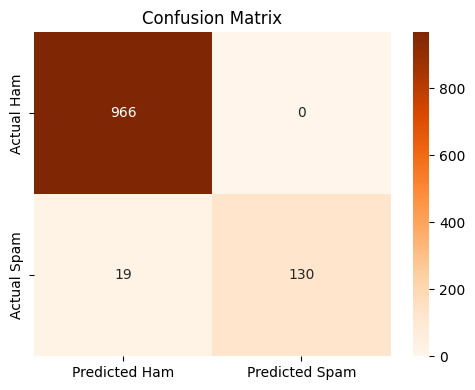

In [66]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges",
            xticklabels=["Predicted Ham", "Predicted Spam"],
            yticklabels=["Actual Ham", "Actual Spam"])
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig("images/confusion_matrix.png", dpi=150)
plt.show()

### 5c. SVM Decision Boundary — 2D PCA Projection

The real feature space has thousands of dimensions (one per word). We use **PCA** to project down to 2D. A new SVM is trained on these 2D points so we can draw the decision boundary and margin.

Note: PCA captures only a small fraction of the total variance, so cluster overlap in this view is expected and does not reflect the model's actual performance.

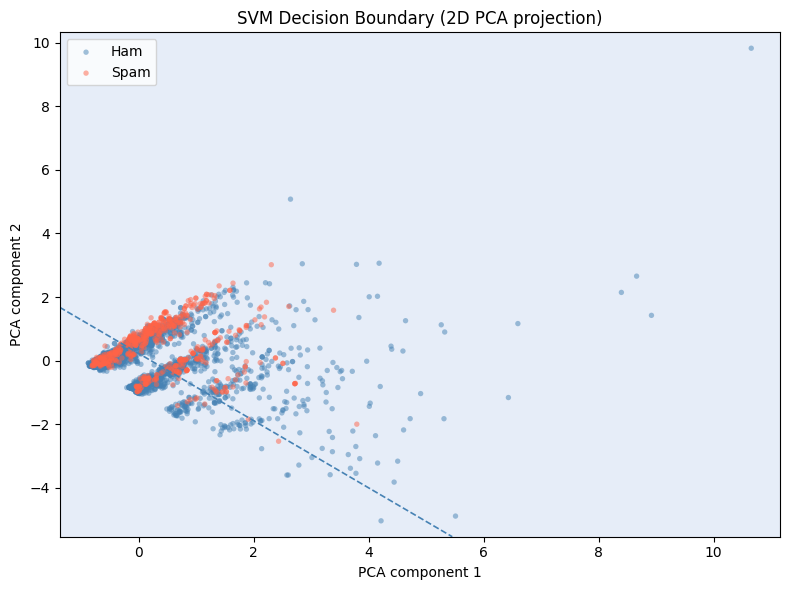

In [67]:
from sklearn.decomposition import PCA
from sklearn.svm import SVC

pca = PCA(n_components=2, random_state=42)
X_train_2d = pca.fit_transform(X_train.toarray())

svm_2d = SVC(kernel="linear", C=1.0)
svm_2d.fit(X_train_2d, y_train)

pad = 0.5
x_min, x_max = X_train_2d[:, 0].min() - pad, X_train_2d[:, 0].max() + pad
y_min, y_max = X_train_2d[:, 1].min() - pad, X_train_2d[:, 1].max() + pad
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400),
                     np.linspace(y_min, y_max, 400))
Z = svm_2d.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(8, 6))
ax.contourf(xx, yy, Z, levels=[-999, 0, 999],
            colors=["#aec6e8", "#f4a89a"], alpha=0.3)
ax.contour(xx, yy, Z, levels=[-1, 0, 1],
           linestyles=["--", "-", "--"],
           colors=["steelblue", "black", "tomato"],
           linewidths=[1.2, 2, 1.2])

for cls, color, label in [(0, "steelblue", "Ham"), (1, "tomato", "Spam")]:
    mask = (y_train == cls).values
    ax.scatter(X_train_2d[mask, 0], X_train_2d[mask, 1],
               c=color, label=label, alpha=0.5, s=15, edgecolors="none")

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_xlabel("PCA component 1")
ax.set_ylabel("PCA component 2")
ax.set_title("SVM Decision Boundary (2D PCA projection)")
ax.legend()
plt.tight_layout()
plt.savefig("images/decision_boundary_pca.png", dpi=150)
plt.show()

## 6. Learning Curve

We plot both **training accuracy** and **test accuracy** as training size grows:
- Large gap between lines → **overfitting**
- Both low → **underfitting**
- Converging lines → good **generalization**

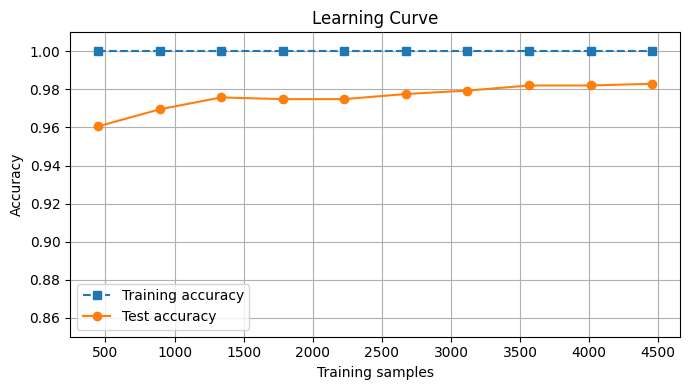

In [68]:
fractions = np.linspace(0.1, 1.0, 10)
learning_curve_train = []
learning_curve_acc   = []

for frac in fractions:
    n = max(1, int(X_train.shape[0] * frac))
    clf = LinearSVC(C=1.0, max_iter=1000)
    clf.fit(X_train[:n], y_train.iloc[:n])
    learning_curve_train.append(accuracy_score(y_train.iloc[:n], clf.predict(X_train[:n])))
    learning_curve_acc.append(accuracy_score(y_test, clf.predict(X_test)))

sample_counts = [int(X_train.shape[0] * f) for f in fractions]

plt.figure(figsize=(7, 4))
plt.plot(sample_counts, learning_curve_train, marker="s", linestyle="--", label="Training accuracy")
plt.plot(sample_counts, learning_curve_acc,   marker="o", label="Test accuracy")
plt.xlabel("Training samples")
plt.ylabel("Accuracy")
plt.title("Learning Curve")
plt.ylim(0.85, 1.01)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("images/learning_curve.png", dpi=150)
plt.show()

## 7. Hyperparameter Sweep: Regularization `C`

The `C` parameter controls the **bias-variance tradeoff**:
- **Small `C`** → high bias (underfitting): simpler model, wider margin
- **Large `C`** → high variance (overfitting): complex model, memorizes training data

Plotting both training and test accuracy reveals this tradeoff directly.

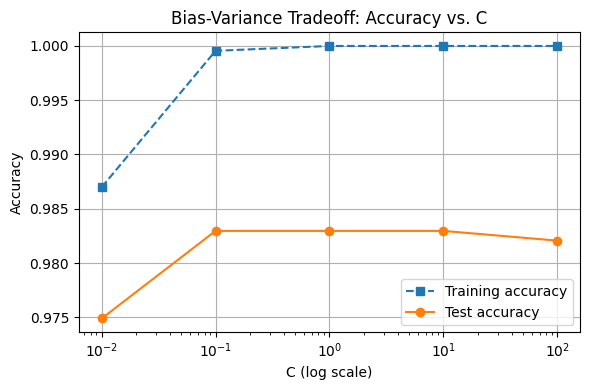

     C    Train     Test
  0.01  0.9870  0.9749
   0.1  0.9996  0.9830
     1  1.0000  0.9830
    10  1.0000  0.9830
   100  1.0000  0.9821


In [69]:
C_values = [0.01, 0.1, 1, 10, 100]
c_train_acc = []
c_test_acc  = []

for c in C_values:
    clf = LinearSVC(C=c, max_iter=2000)
    clf.fit(X_train, y_train)
    c_train_acc.append(accuracy_score(y_train, clf.predict(X_train)))
    c_test_acc.append(accuracy_score(y_test, clf.predict(X_test)))

plt.figure(figsize=(6, 4))
plt.semilogx(C_values, c_train_acc, marker="s", linestyle="--", label="Training accuracy")
plt.semilogx(C_values, c_test_acc,  marker="o", label="Test accuracy")
plt.xlabel("C (log scale)")
plt.ylabel("Accuracy")
plt.title("Bias-Variance Tradeoff: Accuracy vs. C")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("images/c_sweep.png", dpi=150)
plt.show()

print(f"{'C':>6}  {'Train':>7}  {'Test':>7}")
for c, tr, te in zip(C_values, c_train_acc, c_test_acc):
    print(f"{c:>6}  {tr:.4f}  {te:.4f}")

---
# Iteration 2: TF-IDF Features

**Goal:** Determine whether TF-IDF feature weighting improves on bag-of-words.

**TF-IDF** (Term Frequency-Inverse Document Frequency) weights each word by how often it appears in a message (TF) divided by how common it is across all messages (IDF). Common words like "the" get down-weighted; rare distinctive words like "prize" get up-weighted.

We repeat the same pipeline and overlay results against Iteration 1 for direct comparison.

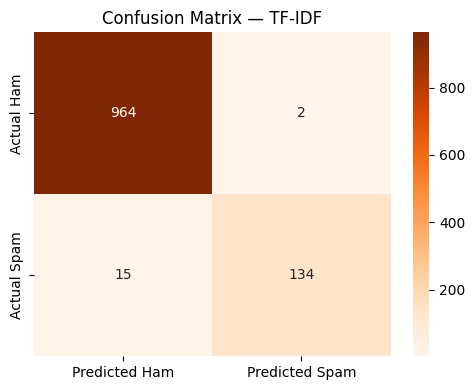

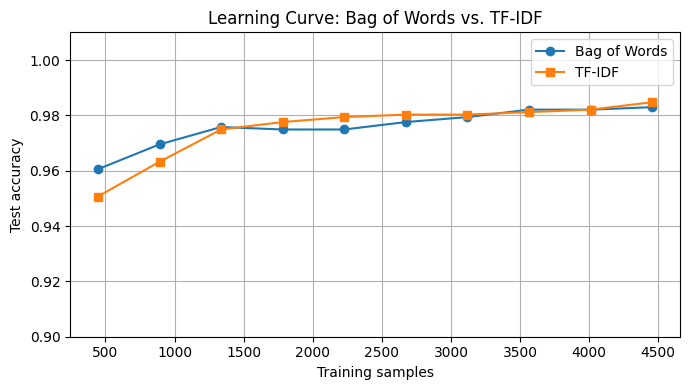

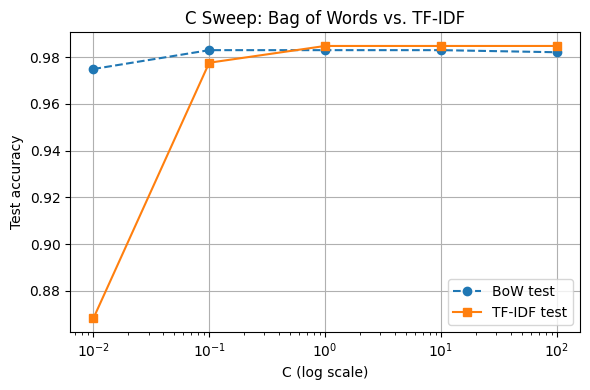

Bag of Words accuracy : 0.9830
TF-IDF accuracy       : 0.9848

              precision    recall  f1-score   support

         ham     0.9847    0.9979    0.9913       966
        spam     0.9853    0.8993    0.9404       149

    accuracy                         0.9848      1115
   macro avg     0.9850    0.9486    0.9658      1115
weighted avg     0.9848    0.9848    0.9845      1115



In [72]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()
X_train_tfidf = tfidf.fit_transform(X_train_raw)
X_test_tfidf  = tfidf.transform(X_test_raw)

# Learning curve comparison
tfidf_curve = []
for frac in fractions:
    n = max(1, int(X_train_tfidf.shape[0] * frac))
    clf = LinearSVC(C=1.0, max_iter=1000)
    clf.fit(X_train_tfidf[:n], y_train.iloc[:n])
    tfidf_curve.append(accuracy_score(y_test, clf.predict(X_test_tfidf)))

# Confusion matrix
cm_tfidf = confusion_matrix(y_test, y_pred_tfidf)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_tfidf, annot=True, fmt="d", cmap="Oranges",
            xticklabels=["Predicted Ham", "Predicted Spam"],
            yticklabels=["Actual Ham", "Actual Spam"])
plt.title("Confusion Matrix — TF-IDF")
plt.tight_layout()
plt.savefig("images/confusion_matrix_tfidf.png", dpi=150)
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(sample_counts, learning_curve_acc, marker="o", label="Bag of Words")
plt.plot(sample_counts, tfidf_curve,        marker="s", label="TF-IDF")
plt.xlabel("Training samples")
plt.ylabel("Test accuracy")
plt.title("Learning Curve: Bag of Words vs. TF-IDF")
plt.ylim(0.9, 1.01)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("images/learning_curve_tfidf.png", dpi=150)
plt.show()

# C sweep comparison
tfidf_train_acc, tfidf_test_acc = [], []
for c in C_values:
    clf = LinearSVC(C=c, max_iter=2000)
    clf.fit(X_train_tfidf, y_train)
    tfidf_train_acc.append(accuracy_score(y_train, clf.predict(X_train_tfidf)))
    tfidf_test_acc.append(accuracy_score(y_test,  clf.predict(X_test_tfidf)))

plt.figure(figsize=(6, 4))
plt.semilogx(C_values, c_test_acc,     marker="o", linestyle="--", label="BoW test")
plt.semilogx(C_values, tfidf_test_acc, marker="s", label="TF-IDF test")
plt.xlabel("C (log scale)")
plt.ylabel("Test accuracy")
plt.title("C Sweep: Bag of Words vs. TF-IDF")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("images/c_sweep_tfidf.png", dpi=150)
plt.show()

# Final accuracy + report
clf_tfidf = LinearSVC(C=1.0, max_iter=1000).fit(X_train_tfidf, y_train)
y_pred_tfidf = clf_tfidf.predict(X_test_tfidf)
print(f"Bag of Words accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"TF-IDF accuracy       : {accuracy_score(y_test, y_pred_tfidf):.4f}")
print()
print(classification_report(y_test, y_pred_tfidf, target_names=["ham", "spam"], digits=4))